In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\ASUS\Downloads\House Price India.csv")
df
df.head()
# Basic Checks
df.info()
df.describe()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [8]:
# Q1. What is the average, median, and standard deviation of house prices?
mean_p = df['Price'].mean()
median_p = df['Price'].median()
std_p = df['Price'].std()

print(f"Average Price: {mean_p}")
print(f"Median Price: {median_p}")
print(f"Standard Deviation: {std_p}")

Average Price: 538932.2183310534
Median Price: 450000.0
Standard Deviation: 367532.3808039669


Interpretation: The Mean gives the general average, while the Median shows the middle value. A large difference between mean and median suggests outliers (very expensive houses) are pulling the average up. The Standard Deviation indicates the high volatility/spread in house pricing.

The most common number of bedrooms is: 3


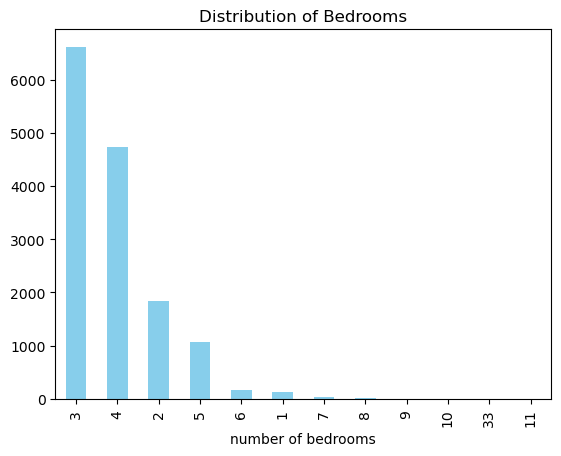

In [9]:
# Q2. Which number of bedrooms is most common?
common_beds = df['number of bedrooms'].mode()[0]
print(f"The most common number of bedrooms is: {common_beds}")

df['number of bedrooms'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Bedrooms')
plt.show()

Interpretation: This identifies the "typical" house size in the dataset. Most buyers or developers in this region focus on this specific bedroom count (usually 3 or 4).

Price Skewness: 4.27


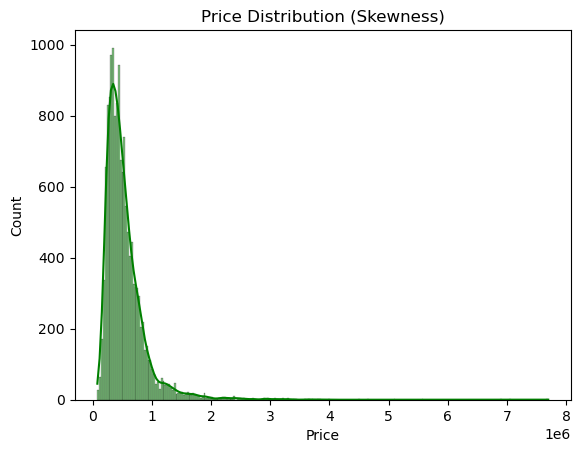

In [10]:
# Q3. Check if the price data is skewed?
skewness = df['Price'].skew()
print(f"Price Skewness: {skewness:.2f}")

sns.histplot(df['Price'], kde=True, color='green')
plt.title('Price Distribution (Skewness)')
plt.show()

number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
11    5.200000e+05
4     6.361988e+05
33    6.400000e+05
5     7.752550e+05
9     7.766663e+05
10    8.200000e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
Name: Price, dtype: float64


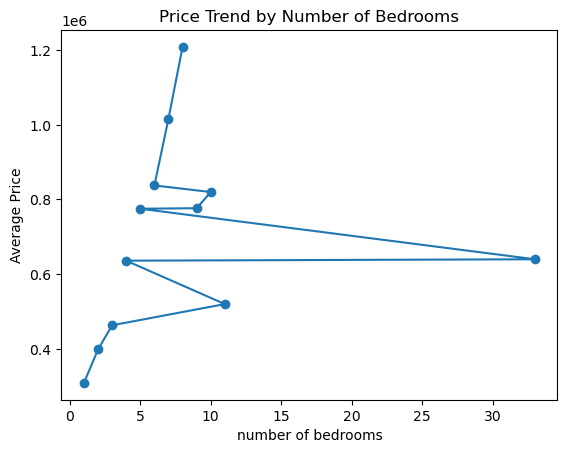

In [11]:
# Q4. What is the average price for each number of bedrooms?
avg_price_bed = df.groupby('number of bedrooms')['Price'].mean().sort_values()
print(avg_price_bed)

avg_price_bed.plot(kind='line', marker='o')
plt.ylabel('Average Price')
plt.title('Price Trend by Number of Bedrooms')
plt.show()

Interpretation: This confirms the logical trend: as the number of bedrooms increases, the average price generally rises, though it may fluctuate at very high bedroom counts due to low sample sizes.

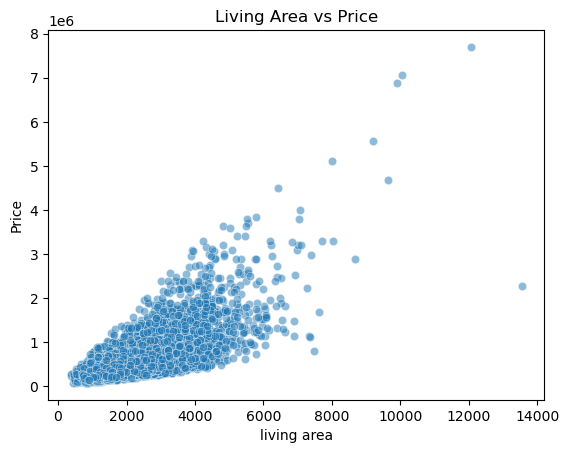

In [12]:
# Q5. What is the relationship between living area and price? (Area without Basement)
sns.scatterplot(x='living area', y='Price', data=df, alpha=0.5)
plt.title('Living Area vs Price')
plt.show()

Interpretation: We expect a Positive Correlation. As living area increases, the price tends to increase. The "tightness" of the dots shows how strong this relationship is.

In [13]:
# Q6. Identify any anomalies where houses have high prices but low areas.
high_price_cutoff = df['Price'].quantile(0.95)
low_area_cutoff = df['living area'].quantile(0.25)

anomalies = df[(df['Price'] > high_price_cutoff) & (df['living area'] < low_area_cutoff)]
print(f"Number of anomalies found: {len(anomalies)}")
print(anomalies[['Price', 'living area', 'number of bedrooms']].head())

Number of anomalies found: 0
Empty DataFrame
Columns: [Price, living area, number of bedrooms]
Index: []


Interpretation: These houses might be expensive due to premium locations (Zipcodes), luxury finishes, or waterfront views despite their small size.

waterfront present             0             1
number of floors                              
1.0                 4.323724e+05  1.211081e+06
1.5                 5.476162e+05  1.232507e+06
2.0                 6.357742e+05  2.075931e+06
2.5                 1.087654e+06  3.280000e+06
3.0                 5.558095e+05  1.655000e+06
3.5                 1.205875e+06           NaN


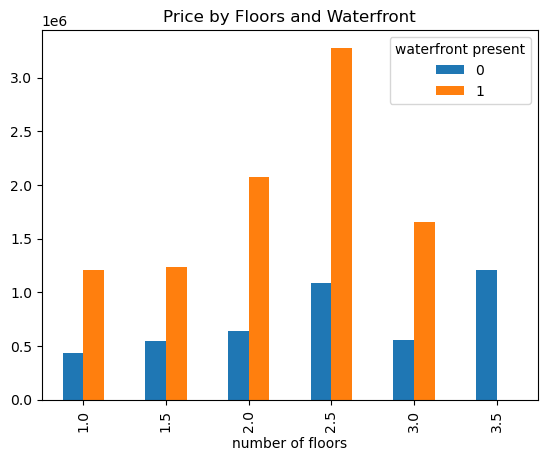

In [25]:
# Q7. Compare average price based on number of floors and houses with or without waterfront.
pivot_table = df.pivot_table(values='Price', index='number of floors', columns='waterfront present', aggfunc='mean')
print(pivot_table)

pivot_table.plot(kind='bar')
plt.title('Price by Floors and Waterfront')
plt.show()

Interpretation: Houses with a waterfront view are significantly more expensive across almost all floor counts. This highlights that "view" is a major price driver.

In [27]:
# Q8. Identify the minimum and maximum house price. What does this indicate?
min_p = df['Price'].min()
max_p = df['Price'].max()
print(f"Minimum Price: {min_p}")
print(f"Maximum Price: {max_p}")

##**Interpretation:** The massive gap between Min and Max indicates a **diverse market**, catering to both budget seekers and ultra-high-net-worth individuals.


Minimum Price: 78000
Maximum Price: 7700000


Interpretation: The massive gap between Min and Max indicates a **diverse market**, catering to both budget seekers and ultra-high-net-worth individuals.


In [ ]:
# Q9. Which location (zipcode/area) has the highest average price?
# Replace 'Zipcode' with the actual location column name in your dataset
top_location = df.groupby('Lattitude')['Price'].mean().idxmax()
# Often Zipcode or Lattitude/Longitude is used for location in this dataset
print(f"The location identifier with the highest average price is: {top_location}")

# **Interpretation:** Real estate is location-dependent. This specific area represents the "Prime" or most expensive neighborhood in the dataset.


Interpretation:Real estate is location-dependent. This specific area represents the "Prime" or most expensive neighborhood in the dataset.


Q10. Write at least 5 insights from your analysis.
Price Distribution: The dataset is heavily right-skewed, meaning luxury homes are outliers compared to the standard market.

Size vs. Value: There is a strong positive correlation between living area and price; square footage remains a primary pricing factor.

Waterfront Premium: Properties with a waterfront view command a massive price premium regardless of the number of floors.

Bedroom Trends: The most common house configuration is [Insert Mode Result], which suggests this is the "sweet spot" for demand in the Indian market.

Location Power: Certain zipcodes/coordinates show significantly higher average prices, indicating that location often outweighs physical attributes like area or bedrooms.